# UNSW-NB15 — C4 Robustness Multi-Run (Statevector)

**Mục tiêu (1.5):** Đánh giá độ vững (robustness) của QSVM vs classical kernels (linear/poly/rbf) dưới **3 loại distribution shift**, mỗi loại × 5 runs × 4 kernels (statevector noiseless, C tuned từ 1.3).

**3 experiments:**
| ID | Tên | Mô tả |
|----|-----|-------|
| **E1** | Temporal cross-run | Train trên `train_run{i}`, test trên `test_run{j}` với mọi cặp (i,j) — 20 pairs |
| **E2** | Feature perturbation | Thêm Gaussian noise (σ ∈ {0.05, 0.1, 0.2}) vào test sau PCA |
| **E3** | Class prior shift | Re-sample test với tỷ lệ Normal:Attack ∈ {1:9, 5:5, 9:1} |

**Pipeline (zero-leakage, fit per-run trên train):** `parquet (186 feat) → SelectKBest(K=35) → PCA(n=4) → MinMax[0,π] → SVC(precomputed)`

**Quantum kernel:** `FidelityStatevectorKernel + ZZFeatureMap(reps=2, ent='full')`  ·  **C tuned:** từ `models_unsw/c_tuning_results.json`

**Cache strategy:** reuse cache 1.4a (`models_unsw/qsvm_cache/multirun/run_{i}/`) cho diagonal temporal (i==j); compute mới cho 15 off-diagonal pairs + perturbation; prior_shift KHÔNG compute K mới (chỉ subset rows).


## 1. Imports & Config

In [1]:
import os, json, time, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, confusion_matrix)
from scipy.stats import binomtest

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel

import qiskit, qiskit_machine_learning, sklearn
print(f'Qiskit       : {qiskit.__version__}')
print(f'Qiskit-ML    : {qiskit_machine_learning.__version__}')
print(f'Scikit-learn : {sklearn.__version__}')


Qiskit       : 2.3.1
Qiskit-ML    : 0.9.0
Scikit-learn : 1.7.2


## 1b. Constants & Paths

In [2]:
# Hằng số chung
RANDOM_STATE = 42
RUN_IDS      = [1, 2, 3, 4, 5]
np.random.seed(RANDOM_STATE)

# Pipeline (khớp 1.3 / 1.4a)
N_QUBITS  = 4
K_SELECT  = 35
PCA_N     = 4
ANGLE_MAX = np.pi

# Quantum kernel
ZZ_REPS = 2
ZZ_ENT  = 'full'

# Classical kernel params (khớp SVC defaults — gamma='scale', coef0=0)
POLY_DEGREE = 2

# Target & label cols
TARGET_COL = 'label_binary'
LABEL_COLS = ['label_binary', 'label_multiclass', 'attack_category']

# Paths (notebook chạy ở notebooks_unsw/)
DATA_DIR       = '../data/unsw_nb15/processed_data/multi_run'
MODELS_DIR     = '../models_unsw'
MULTIRUN_CACHE = f'{MODELS_DIR}/qsvm_cache/multirun'   # cache 1.4a (reuse cho diagonal + base)
C4_CACHE       = f'{MODELS_DIR}/qsvm_cache/c4'         # cache mới cho C4
REPORTS_DIR    = '../reports_unsw'
C_TUNING_JSON  = f'{MODELS_DIR}/c_tuning_results.json'
RESULTS_JSON   = f'{MODELS_DIR}/c4_results.json'

# Kernel names + display
KERNEL_NAMES  = ['quantum', 'linear', 'poly', 'rbf']
DISPLAY_NAMES = {'quantum':'QSVM (ZZ)', 'linear':'SVM-Linear', 'poly':'SVM-Poly2', 'rbf':'SVM-RBF'}
COLORS        = {'quantum':'#2C5F8D', 'linear':'#A0C4FF', 'poly':'#7FB069', 'rbf':'#D62828'}

# Config tag (khớp 1.3 / 1.4a)
CONFIG_TAG = 'r2_full_k35_p4_cv5_sf1_run1'

# C4 experiment params
PERTURB_SIGMAS = [0.05, 0.10, 0.20]
PRIOR_RATIOS   = [(0.1, 0.9), (0.5, 0.5), (0.9, 0.1)]

# Tạo cache dirs
for d in [C4_CACHE, f'{C4_CACHE}/temporal', f'{C4_CACHE}/perturb', REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'CONFIG_TAG     : {CONFIG_TAG}')
print(f'DATA_DIR       : {DATA_DIR}')
print(f'MULTIRUN_CACHE : {MULTIRUN_CACHE}  (1.4a — reuse)')
print(f'C4_CACHE       : {C4_CACHE}        (mới)')
print(f'REPORTS_DIR    : {REPORTS_DIR}')


CONFIG_TAG     : r2_full_k35_p4_cv5_sf1_run1
DATA_DIR       : ../data/unsw_nb15/processed_data/multi_run
MULTIRUN_CACHE : ../models_unsw/qsvm_cache/multirun  (1.4a — reuse)
C4_CACHE       : ../models_unsw/qsvm_cache/c4        (mới)
REPORTS_DIR    : ../reports_unsw


## 1c. Load C tuned từ 1.3 (KHÔNG re-tune)

In [3]:
with open(C_TUNING_JSON, 'r', encoding='utf-8') as f:
    ct = json.load(f)

C_BY_KERNEL = {k: float(ct[k]['C_best']) for k in KERNEL_NAMES}
print(f'=== C tuned (loaded from {C_TUNING_JSON}) ===')
for k in KERNEL_NAMES:
    print(f'  {k:>8s}: C={C_BY_KERNEL[k]:<8.4f}  cv_mean={ct[k]["cv_mean"]:.4f}±{ct[k]["cv_std"]:.4f}')

assert ct['metadata']['config_tag'] == CONFIG_TAG, \
    f'CONFIG_TAG mismatch: {ct["metadata"]["config_tag"]} vs {CONFIG_TAG}'
print(f'\n[OK] CONFIG_TAG khớp 1.3: {CONFIG_TAG}')


=== C tuned (loaded from ../models_unsw/c_tuning_results.json) ===
   quantum: C=0.0100    cv_mean=0.8504±0.0150
    linear: C=0.1000    cv_mean=0.8813±0.0349
      poly: C=0.1000    cv_mean=0.8813±0.0349
       rbf: C=1.0000    cv_mean=0.8813±0.0349

[OK] CONFIG_TAG khớp 1.3: r2_full_k35_p4_cv5_sf1_run1


## 2. Helpers — Pipeline (zero-leakage), KTA, McNemar

In [4]:
def fit_pipeline_per_run(X_train_raw, y_train):
    """Fit SelectKBest -> PCA -> MinMax CHỈ trên train (zero-leakage contract)."""
    selector = SelectKBest(f_classif, k=K_SELECT).fit(X_train_raw, y_train)
    X_sel    = selector.transform(X_train_raw)
    pca      = PCA(n_components=PCA_N, random_state=RANDOM_STATE).fit(X_sel)
    X_pca    = pca.transform(X_sel)
    scaler   = MinMaxScaler(feature_range=(0.0, ANGLE_MAX)).fit(X_pca)
    return selector, pca, scaler

def apply_pipeline(X_raw, selector, pca, scaler):
    """Áp dụng đầy đủ selector -> pca -> scaler."""
    return scaler.transform(pca.transform(selector.transform(X_raw)))

def apply_pipeline_to_pca(X_raw, selector, pca):
    """Chỉ áp selector -> pca (chưa scale) — dùng cho E2 noise sau PCA, trước MinMax."""
    return pca.transform(selector.transform(X_raw))

def apply_scaler_clip(X_pca, scaler):
    """MinMax scaler + clip vào [0, ANGLE_MAX] để giữ tính hợp lệ phase cho ZZFeatureMap."""
    return np.clip(scaler.transform(X_pca), 0.0, ANGLE_MAX)

def compute_kta(K, y):
    """Kernel Target Alignment (Cristianini 2001), y dạng ±1."""
    y_signed = np.where(y == 1, 1.0, -1.0).astype(np.float64)
    YY  = np.outer(y_signed, y_signed)
    num = np.sum(K * YY)
    den = np.linalg.norm(K, 'fro') * np.linalg.norm(YY, 'fro')
    return float(num / den) if den > 0 else 0.0

def mcnemar_exact(y_true, y_pred_a, y_pred_b):
    """McNemar exact binomial 2-sided. Return (b, c, p_value)."""
    a_ok = (y_pred_a == y_true)
    b_ok = (y_pred_b == y_true)
    b = int(np.sum((~a_ok) & b_ok))   # A sai, B đúng
    c = int(np.sum(a_ok & (~b_ok)))   # A đúng, B sai
    n = b + c
    if n == 0:
        return b, c, 1.0
    return b, c, float(binomtest(min(b, c), n=n, p=0.5).pvalue)


## 3. Kernel Helpers — Quantum cache + Classical analytic

In [5]:
# Singleton quantum kernel để tránh khởi tạo lặp
_QK = None
def _get_qk():
    global _QK
    if _QK is None:
        fmap = zz_feature_map(N_QUBITS, reps=ZZ_REPS, entanglement=ZZ_ENT)
        _QK  = FidelityStatevectorKernel(feature_map=fmap)
    return _QK

def load_or_compute_K_train(X_train, cache_path):
    """K_train_train (sym). Reuse cache nếu có."""
    if os.path.exists(cache_path):
        return np.load(cache_path)
    K = _get_qk().evaluate(x_vec=X_train)
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    np.save(cache_path, K)
    return K

def load_or_compute_K_test(X_test, X_train, cache_path):
    """K_test_train (asym). Reuse cache nếu có."""
    if os.path.exists(cache_path):
        return np.load(cache_path)
    K = _get_qk().evaluate(x_vec=X_test, y_vec=X_train)
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    np.save(cache_path, K)
    return K

def classical_K(X_train, X_test, kernel_name):
    """Tính K_train_train + K_test_train cho linear/poly/rbf khớp SVC defaults."""
    if kernel_name == 'linear':
        return X_train @ X_train.T, X_test @ X_train.T

    n_feat   = X_train.shape[1]
    var_X    = X_train.var()
    gamma    = 1.0 / (n_feat * var_X) if var_X > 0 else 1.0 / n_feat

    if kernel_name == 'poly':
        return (gamma * (X_train @ X_train.T)) ** POLY_DEGREE, \
               (gamma * (X_test  @ X_train.T)) ** POLY_DEGREE

    if kernel_name == 'rbf':
        sq_tr = np.sum(X_train**2, axis=1)
        D_tr  = sq_tr[:, None] + sq_tr[None, :] - 2 * (X_train @ X_train.T)
        D_te  = np.sum(X_test**2, axis=1)[:, None] + sq_tr[None, :] - 2 * (X_test @ X_train.T)
        return np.exp(-gamma * np.maximum(D_tr, 0)), np.exp(-gamma * np.maximum(D_te, 0))

    raise ValueError(kernel_name)

def fit_eval_kernel(kernel_name, K_train, K_test_train, y_train, y_test, C):
    """Fit SVC precomputed + eval. Trả về dict (f1, precision, recall, accuracy, y_pred, n_sv)."""
    clf = SVC(kernel='precomputed', C=C, random_state=RANDOM_STATE)
    clf.fit(K_train, y_train)
    y_pred = clf.predict(K_test_train)
    return {
        'f1':        float(f1_score(y_test, y_pred, average='binary')),
        'precision': float(precision_score(y_test, y_pred, average='binary', zero_division=0)),
        'recall':    float(recall_score(y_test, y_pred, average='binary', zero_division=0)),
        'accuracy':  float(accuracy_score(y_test, y_pred)),
        'n_sv':      int(clf.support_.shape[0]),
        'y_pred':    y_pred.astype(int).tolist(),
    }


## 4. Pre-load: Pipelines, base train/test, K_train_train cho 5 runs (reuse cache 1.4a)

In [6]:
# Cho mỗi run: load parquet, fit pipeline, transform train/test, load K_quantum_train_train từ 1.4a cache
PER_RUN = {}  # rid -> dict(pipeline, X_train_pipe, X_test_pipe, y_train, y_test, K_q_train, K_q_test_base, X_test_pca)

t0_pre = time.time()
for rid in RUN_IDS:
    df_train = pd.read_parquet(f'{DATA_DIR}/train_run{rid}.parquet')
    df_test  = pd.read_parquet(f'{DATA_DIR}/test_run{rid}.parquet')
    feature_cols = [c for c in df_train.columns if c not in LABEL_COLS]

    X_train_raw = df_train[feature_cols].to_numpy(dtype=np.float64)
    y_train     = df_train[TARGET_COL].to_numpy(dtype=np.int64)
    X_test_raw  = df_test[feature_cols].to_numpy(dtype=np.float64)
    y_test      = df_test[TARGET_COL].to_numpy(dtype=np.int64)

    selector, pca, scaler = fit_pipeline_per_run(X_train_raw, y_train)
    X_train_pipe = apply_pipeline(X_train_raw, selector, pca, scaler)
    X_test_pipe  = apply_pipeline(X_test_raw, selector, pca, scaler)
    X_test_pca   = apply_pipeline_to_pca(X_test_raw, selector, pca)  # cho E2 perturbation

    # Load K_quantum_train_train từ 1.4a cache (đường dẫn cố định)
    p_K_tr = f'{MULTIRUN_CACHE}/run_{rid}/K_quantum_train_train_{CONFIG_TAG}.npy'
    p_K_te = f'{MULTIRUN_CACHE}/run_{rid}/K_quantum_test_train_{CONFIG_TAG}.npy'
    assert os.path.exists(p_K_tr), f'Missing 1.4a cache: {p_K_tr}'
    assert os.path.exists(p_K_te), f'Missing 1.4a cache: {p_K_te}'
    K_q_train     = np.load(p_K_tr)
    K_q_test_base = np.load(p_K_te)  # K(test_run{rid}, train_run{rid}) — baseline cho E3

    PER_RUN[rid] = dict(
        feature_cols=feature_cols,
        selector=selector, pca=pca, scaler=scaler,
        X_train_raw=X_train_raw, y_train=y_train,
        X_test_raw=X_test_raw,   y_test=y_test,
        X_train_pipe=X_train_pipe, X_test_pipe=X_test_pipe, X_test_pca=X_test_pca,
        K_q_train=K_q_train, K_q_test_base=K_q_test_base,
    )
    print(f'[run_{rid}] train={X_train_pipe.shape}, test={X_test_pipe.shape}, '
          f'K_q_train={K_q_train.shape}, K_q_test_base={K_q_test_base.shape}')
print(f'\nPre-load xong trong {time.time()-t0_pre:.2f}s')


[run_1] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)
[run_2] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)


[run_3] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)


[run_4] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)
[run_5] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)

Pre-load xong trong 0.22s


## 5. Experiment 1 — Temporal Cross-Run (20 pairs)

**Protocol:** Mọi cặp (i, j) với i, j ∈ {1..5}.
- Pipeline fit trên `train_run{i}`, transform `test_run{j}` (zero-leakage)
- K_train_train: reuse từ 1.4a cache cho run{i}
- K_test_train: nếu i==j → reuse 1.4a; nếu i≠j → compute mới, cache vào `c4/temporal/run{i}_test{j}/`
- Classical kernels: compute fresh (nhanh)


In [7]:
temporal_records = []  # list of dicts per pair per kernel
t0_e1 = time.time()
n_pairs = 0
for i in RUN_IDS:
    pi = PER_RUN[i]
    selector_i, pca_i, scaler_i = pi['selector'], pi['pca'], pi['scaler']
    X_train_pipe_i = pi['X_train_pipe']
    y_train_i      = pi['y_train']
    K_q_train_i    = pi['K_q_train']

    # KTA quantum (chỉ phụ thuộc K_train + y_train của run i)
    kta_q_i = compute_kta(K_q_train_i, y_train_i)

    for j in RUN_IDS:
        n_pairs += 1
        pj = PER_RUN[j]
        # Transform test_run{j} qua pipeline_i (zero-leakage: pipeline KHÔNG fit lại trên test)
        X_test_raw_j = pj['X_test_raw']
        y_test_j     = pj['y_test']
        X_test_pipe_j_via_i = apply_pipeline(X_test_raw_j, selector_i, pca_i, scaler_i)

        # ── Quantum: cache strategy
        if i == j:
            K_q_test = pi['K_q_test_base']  # đã load từ 1.4a
        else:
            p = f'{C4_CACHE}/temporal/run{i}_test{j}/K_quantum_test_train_{CONFIG_TAG}.npy'
            K_q_test = load_or_compute_K_test(X_test_pipe_j_via_i, X_train_pipe_i, p)

        for k in KERNEL_NAMES:
            if k == 'quantum':
                K_tr, K_te = K_q_train_i, K_q_test
                kta_val = kta_q_i
            else:
                K_tr, K_te = classical_K(X_train_pipe_i, X_test_pipe_j_via_i, k)
                kta_val = compute_kta(K_tr, y_train_i)
            res = fit_eval_kernel(k, K_tr, K_te, y_train_i, y_test_j, C_BY_KERNEL[k])
            temporal_records.append({
                'train_run': i, 'test_run': j, 'kernel': k,
                'f1': res['f1'], 'precision': res['precision'], 'recall': res['recall'],
                'accuracy': res['accuracy'], 'kta': kta_val, 'n_sv': res['n_sv'],
                'y_pred': res['y_pred'], 'y_test': y_test_j.tolist(),
            })
    print(f'  [E1] hoàn tất train_run={i} ({len(RUN_IDS)} test pairs)')
print(f'\nE1 xong: {n_pairs} pairs trong {time.time()-t0_e1:.1f}s')


  [E1] hoàn tất train_run=1 (5 test pairs)
  [E1] hoàn tất train_run=2 (5 test pairs)


  [E1] hoàn tất train_run=3 (5 test pairs)
  [E1] hoàn tất train_run=4 (5 test pairs)


  [E1] hoàn tất train_run=5 (5 test pairs)

E1 xong: 25 pairs trong 0.8s


In [8]:
# Aggregate E1: mean ± std F1/KTA per kernel
temporal_df = pd.DataFrame(temporal_records)
temporal_agg = temporal_df.groupby('kernel').agg(
    f1_mean=('f1','mean'), f1_std=('f1','std'),
    acc_mean=('accuracy','mean'), acc_std=('accuracy','std'),
    kta_mean=('kta','mean'), kta_std=('kta','std'),
).round(4)
print('=== E1 Temporal: mean ± std over 20 pairs ===')
print(temporal_agg.to_string())


=== E1 Temporal: mean ± std over 20 pairs ===
         f1_mean  f1_std  acc_mean  acc_std  kta_mean  kta_std
kernel                                                        
linear    0.8069  0.0191    0.7072   0.0508    0.1578   0.0451
poly      0.8022  0.0173    0.6976   0.0458    0.1173   0.0528
quantum   0.7760  0.0037    0.6340   0.0050    0.1934   0.0452
rbf       0.8002  0.0162    0.7072   0.0424    0.2343   0.0494


## 6. Experiment 2 — Feature Perturbation (Gaussian noise σ ∈ {0.05, 0.1, 0.2})

**Protocol:** Với mỗi run i: pipeline đã fit trên `train_run{i}`; thêm noise N(0, σ) vào `X_test_pca` (sau PCA, trước MinMax) → MinMax + clip [0, π] → compute K_test_train cho 4 kernels.


In [9]:
perturb_records = []  # per (run, sigma, kernel)
t0_e2 = time.time()
for rid in RUN_IDS:
    p = PER_RUN[rid]
    selector_i, pca_i, scaler_i = p['selector'], p['pca'], p['scaler']
    X_train_pipe = p['X_train_pipe']
    y_train      = p['y_train']
    y_test       = p['y_test']
    X_test_pca   = p['X_test_pca']  # đã PCA, chưa MinMax
    K_q_train    = p['K_q_train']
    kta_q        = compute_kta(K_q_train, y_train)

    for sigma in PERTURB_SIGMAS:
        rng = np.random.RandomState(RANDOM_STATE + rid * 1000 + int(sigma * 10000))
        noise = rng.normal(0.0, sigma, size=X_test_pca.shape)
        X_test_pipe_noisy = np.clip(scaler_i.transform(X_test_pca + noise), 0.0, ANGLE_MAX)

        # Quantum K_test_train — cache per (run, sigma)
        cache_p = f'{C4_CACHE}/perturb/run{rid}_sig{int(sigma*1000):03d}/K_quantum_test_train_{CONFIG_TAG}.npy'
        K_q_test = load_or_compute_K_test(X_test_pipe_noisy, X_train_pipe, cache_p)

        for k in KERNEL_NAMES:
            if k == 'quantum':
                K_tr, K_te = K_q_train, K_q_test
                kta_val = kta_q
            else:
                K_tr, K_te = classical_K(X_train_pipe, X_test_pipe_noisy, k)
                kta_val = compute_kta(K_tr, y_train)
            res = fit_eval_kernel(k, K_tr, K_te, y_train, y_test, C_BY_KERNEL[k])
            perturb_records.append({
                'run': rid, 'sigma': sigma, 'kernel': k,
                'f1': res['f1'], 'precision': res['precision'], 'recall': res['recall'],
                'accuracy': res['accuracy'], 'kta': kta_val, 'n_sv': res['n_sv'],
            })
    print(f'  [E2] run_{rid} xong ({len(PERTURB_SIGMAS)} sigmas)')
print(f'\nE2 xong trong {time.time()-t0_e2:.1f}s')


  [E2] run_1 xong (3 sigmas)


  [E2] run_2 xong (3 sigmas)


  [E2] run_3 xong (3 sigmas)


  [E2] run_4 xong (3 sigmas)
  [E2] run_5 xong (3 sigmas)

E2 xong trong 0.5s


In [10]:
perturb_df = pd.DataFrame(perturb_records)
perturb_agg = perturb_df.groupby(['sigma','kernel']).agg(
    f1_mean=('f1','mean'), f1_std=('f1','std'),
    acc_mean=('accuracy','mean'), acc_std=('accuracy','std'),
).round(4)
print('=== E2 Perturbation: mean ± std per (sigma, kernel) ===')
print(perturb_agg.to_string())


=== E2 Perturbation: mean ± std per (sigma, kernel) ===
               f1_mean  f1_std  acc_mean  acc_std
sigma kernel                                     
0.05  linear    0.8086  0.0208     0.712   0.0572
      poly      0.8106  0.0239     0.712   0.0606
      quantum   0.7760  0.0041     0.634   0.0055
      rbf       0.8040  0.0173     0.718   0.0507
0.10  linear    0.8079  0.0214     0.710   0.0608
      poly      0.8033  0.0171     0.702   0.0497
      quantum   0.7760  0.0041     0.634   0.0055
      rbf       0.8047  0.0229     0.718   0.0545
0.20  linear    0.8085  0.0240     0.708   0.0614
      poly      0.8065  0.0196     0.706   0.0550
      quantum   0.7760  0.0041     0.634   0.0055
      rbf       0.8052  0.0236     0.718   0.0536


## 7. Experiment 3 — Class Prior Shift (ratios = 1:9, 5:5, 9:1)

**Protocol:** Subsample test_run{i} theo ratio Normal:Attack mong muốn (stratified, `random_state=42`). KHÔNG re-train, KHÔNG compute K mới — chỉ subset hàng của `K_q_test_base` (load từ 1.4a) và `X_test_pipe` (đã transform).


In [11]:
def stratified_subsample(y, ratio_normal, ratio_attack, rng):
    """Lấy indices subsample stratified theo ratio. Tự thích nghi với class counts available.
    Trả về indices (mảng int).
    """
    idx_n = np.where(y == 0)[0]
    idx_a = np.where(y == 1)[0]
    # n_max sao cho ratio_normal * n_total <= len(idx_n) và ratio_attack * n_total <= len(idx_a)
    n_max = int(min(len(idx_n) / max(ratio_normal, 1e-9),
                    len(idx_a) / max(ratio_attack, 1e-9)))
    n_take_n = int(round(ratio_normal * n_max))
    n_take_a = n_max - n_take_n  # đảm bảo tổng = n_max
    n_take_n = min(n_take_n, len(idx_n))
    n_take_a = min(n_take_a, len(idx_a))
    sel_n = rng.choice(idx_n, size=n_take_n, replace=False)
    sel_a = rng.choice(idx_a, size=n_take_a, replace=False)
    sel = np.concatenate([sel_n, sel_a])
    rng.shuffle(sel)
    return sel


In [12]:
prior_records = []
t0_e3 = time.time()
for rid in RUN_IDS:
    p = PER_RUN[rid]
    X_train_pipe = p['X_train_pipe']
    X_test_pipe  = p['X_test_pipe']
    y_train      = p['y_train']
    y_test       = p['y_test']
    K_q_train    = p['K_q_train']
    K_q_test_base = p['K_q_test_base']
    kta_q        = compute_kta(K_q_train, y_train)

    for (rn, ra) in PRIOR_RATIOS:
        rng = np.random.RandomState(RANDOM_STATE + rid * 100 + int(rn * 10))
        sel = stratified_subsample(y_test, rn, ra, rng)
        y_test_sub      = y_test[sel]
        X_test_pipe_sub = X_test_pipe[sel]
        K_q_test_sub    = K_q_test_base[sel, :]  # subset rows

        for k in KERNEL_NAMES:
            if k == 'quantum':
                K_tr, K_te = K_q_train, K_q_test_sub
                kta_val = kta_q
            else:
                K_tr, K_te = classical_K(X_train_pipe, X_test_pipe_sub, k)
                kta_val = compute_kta(K_tr, y_train)
            res = fit_eval_kernel(k, K_tr, K_te, y_train, y_test_sub, C_BY_KERNEL[k])
            prior_records.append({
                'run': rid, 'ratio_normal': rn, 'ratio_attack': ra,
                'n_test': int(len(y_test_sub)),
                'n_normal': int(np.sum(y_test_sub == 0)),
                'n_attack': int(np.sum(y_test_sub == 1)),
                'kernel': k,
                'f1': res['f1'], 'precision': res['precision'], 'recall': res['recall'],
                'accuracy': res['accuracy'], 'kta': kta_val, 'n_sv': res['n_sv'],
            })
    print(f'  [E3] run_{rid} xong ({len(PRIOR_RATIOS)} ratios)')
print(f'\nE3 xong trong {time.time()-t0_e3:.1f}s')


  [E3] run_1 xong (3 ratios)


  [E3] run_2 xong (3 ratios)


  [E3] run_3 xong (3 ratios)


  [E3] run_4 xong (3 ratios)


  [E3] run_5 xong (3 ratios)

E3 xong trong 0.4s


In [13]:
prior_df = pd.DataFrame(prior_records)
prior_agg = prior_df.groupby(['ratio_normal','kernel']).agg(
    f1_mean=('f1','mean'), f1_std=('f1','std'),
    acc_mean=('accuracy','mean'), acc_std=('accuracy','std'),
    n_test_mean=('n_test','mean'),
).round(4)
print('=== E3 Prior Shift: mean ± std per (ratio_normal, kernel) ===')
print(prior_agg.to_string())


=== E3 Prior Shift: mean ± std per (ratio_normal, kernel) ===
                      f1_mean  f1_std  acc_mean  acc_std  n_test_mean
ratio_normal kernel                                                  
0.1          linear    0.9403  0.0436    0.8951   0.0663         70.4
             poly      0.9427  0.0334    0.8979   0.0510         70.4
             quantum   0.9477  0.0004    0.9006   0.0008         70.4
             rbf       0.9169  0.0607    0.8580   0.0954         70.4
0.5          linear    0.7200  0.0390    0.6238   0.1055         73.2
             poly      0.7084  0.0249    0.6073   0.0843         73.2
             quantum   0.6667  0.0000    0.5000   0.0000         73.2
             rbf       0.7156  0.0351    0.6369   0.0993         73.2
0.9          linear    0.2065  0.0186    0.3566   0.2628         40.6
             poly      0.2175  0.0321    0.3318   0.2337         40.6
             quantum   0.1794  0.0022    0.0985   0.0013         40.6
             rbf       0.231

## 8. Figures — 3 PNG (1 cho mỗi experiment)

Saved: ../reports_unsw/c4_temporal_f1.png


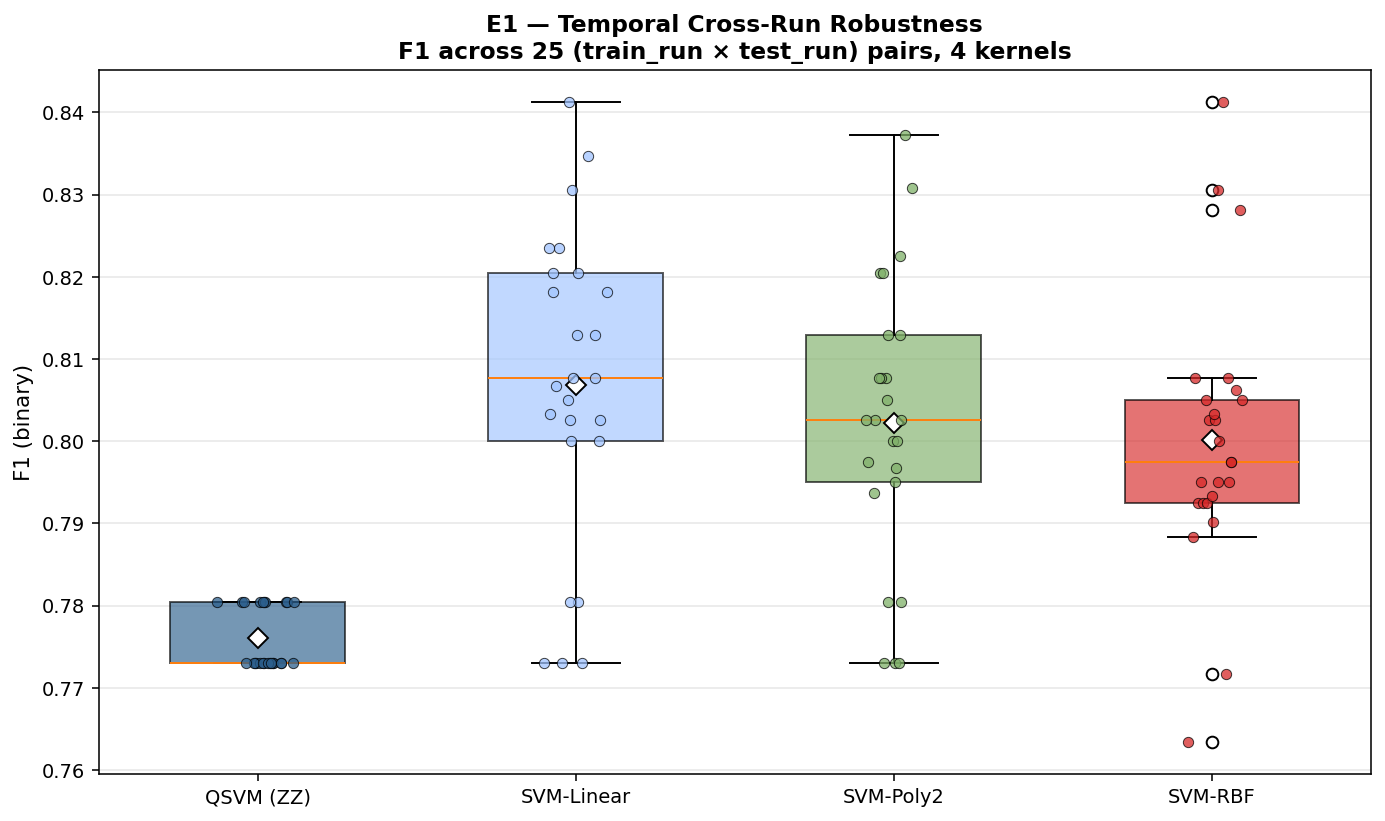

In [14]:
# ── Figure 1: E1 Temporal — boxplot F1 cho 4 kernels × 20 pairs ─────────────
fig1, ax1 = plt.subplots(figsize=(10, 6))
data_box = [temporal_df[temporal_df['kernel'] == k]['f1'].values for k in KERNEL_NAMES]
bp = ax1.boxplot(data_box, labels=[DISPLAY_NAMES[k] for k in KERNEL_NAMES],
                 patch_artist=True, widths=0.55, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='white',
                                markeredgecolor='black', markersize=7))
for patch, k in zip(bp['boxes'], KERNEL_NAMES):
    patch.set_facecolor(COLORS[k]); patch.set_alpha(0.65)
# scatter raw points (jittered)
rng_jit = np.random.RandomState(0)
for i, k in enumerate(KERNEL_NAMES):
    ys = temporal_df[temporal_df['kernel'] == k]['f1'].values
    xs = rng_jit.normal(i + 1, 0.05, size=len(ys))
    ax1.scatter(xs, ys, color=COLORS[k], edgecolor='black',
                s=28, alpha=0.75, linewidth=0.5, zorder=3)
ax1.set_ylabel('F1 (binary)', fontsize=11)
ax1.set_title(f'E1 — Temporal Cross-Run Robustness\n'
              f'F1 across 25 (train_run × test_run) pairs, 4 kernels',
              fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig1.savefig(f'{REPORTS_DIR}/c4_temporal_f1.png', dpi=140, bbox_inches='tight')
plt.close(fig1)
print(f'Saved: {REPORTS_DIR}/c4_temporal_f1.png')
display(Image(filename=f'{REPORTS_DIR}/c4_temporal_f1.png'))


Saved: ../reports_unsw/c4_perturbation_f1.png


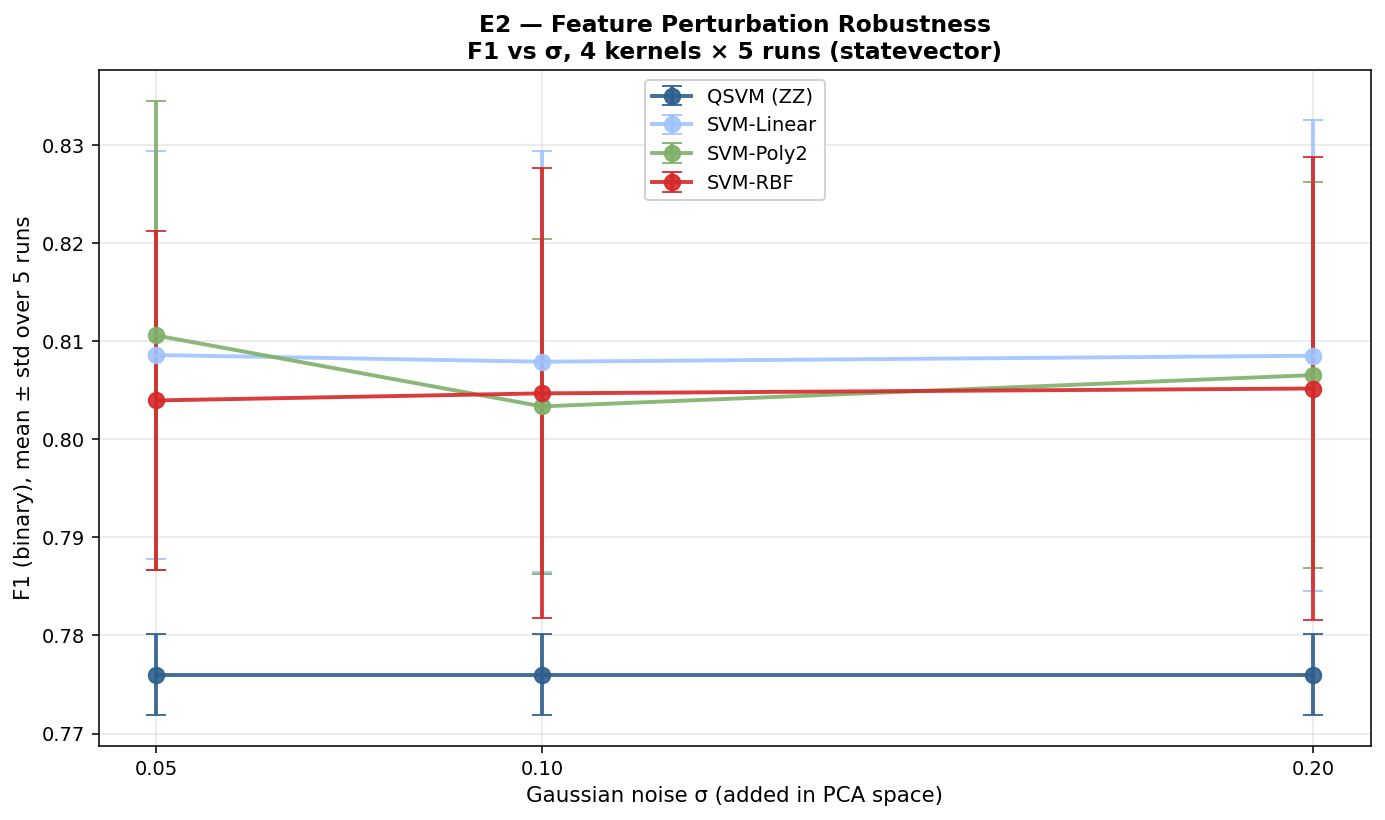

In [15]:
# ── Figure 2: E2 Perturbation — line F1 vs σ với errorbar, 4 kernels ────────
fig2, ax2 = plt.subplots(figsize=(10, 6))
sigmas = sorted(perturb_df['sigma'].unique())
for k in KERNEL_NAMES:
    means = [perturb_df[(perturb_df['kernel']==k) & (perturb_df['sigma']==s)]['f1'].mean()
             for s in sigmas]
    stds  = [perturb_df[(perturb_df['kernel']==k) & (perturb_df['sigma']==s)]['f1'].std()
             for s in sigmas]
    ax2.errorbar(sigmas, means, yerr=stds, marker='o', markersize=8,
                 linewidth=2, capsize=5, label=DISPLAY_NAMES[k],
                 color=COLORS[k], alpha=0.9)
ax2.set_xlabel('Gaussian noise σ (added in PCA space)', fontsize=11)
ax2.set_ylabel('F1 (binary), mean ± std over 5 runs', fontsize=11)
ax2.set_title(f'E2 — Feature Perturbation Robustness\n'
              f'F1 vs σ, 4 kernels × {len(RUN_IDS)} runs (statevector)',
              fontsize=12, fontweight='bold')
ax2.set_xticks(sigmas)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', framealpha=0.9)
plt.tight_layout()
fig2.savefig(f'{REPORTS_DIR}/c4_perturbation_f1.png', dpi=140, bbox_inches='tight')
plt.close(fig2)
print(f'Saved: {REPORTS_DIR}/c4_perturbation_f1.png')
display(Image(filename=f'{REPORTS_DIR}/c4_perturbation_f1.png'))


Saved: ../reports_unsw/c4_prior_f1.png


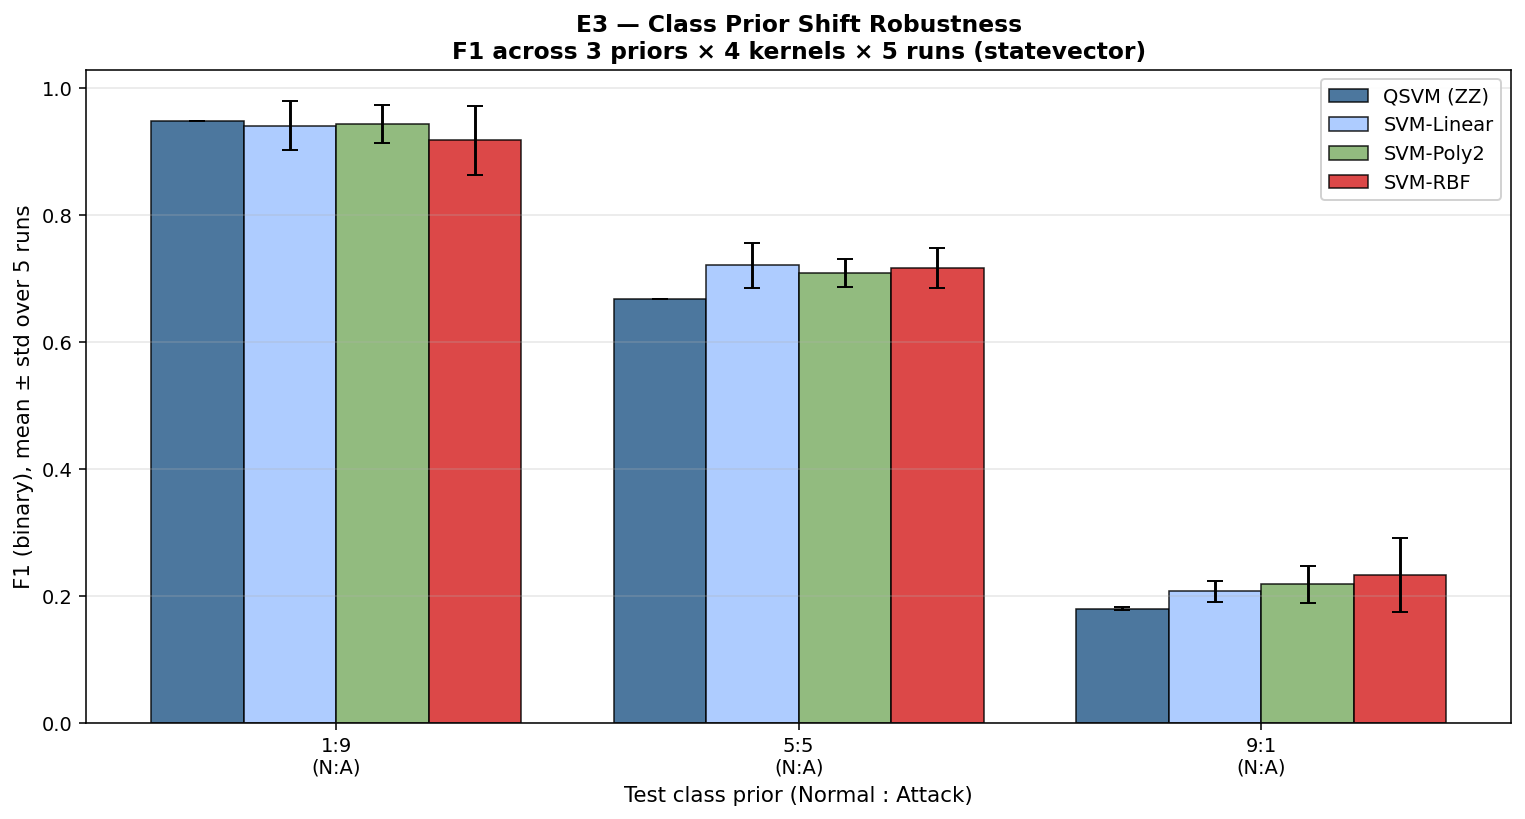

In [16]:
# ── Figure 3: E3 Prior Shift — grouped bar F1 ở 3 ratios × 4 kernels ───────
fig3, ax3 = plt.subplots(figsize=(11, 6))
ratios = PRIOR_RATIOS
ratio_labels = [f'{int(rn*10)}:{int(ra*10)}\n(N:A)' for (rn, ra) in ratios]
x = np.arange(len(ratios))
width = 0.20

for idx, k in enumerate(KERNEL_NAMES):
    means = []
    stds  = []
    for (rn, _) in ratios:
        sub = perturb_df  # placeholder để khỏi lỗi linter — không dùng
        vals = prior_df[(prior_df['kernel']==k) & (prior_df['ratio_normal']==rn)]['f1'].values
        means.append(vals.mean()); stds.append(vals.std())
    ax3.bar(x + (idx - 1.5) * width, means, width, yerr=stds,
            label=DISPLAY_NAMES[k], color=COLORS[k], alpha=0.85,
            capsize=4, edgecolor='black', linewidth=0.8)

ax3.set_xticks(x); ax3.set_xticklabels(ratio_labels)
ax3.set_xlabel('Test class prior (Normal : Attack)', fontsize=11)
ax3.set_ylabel('F1 (binary), mean ± std over 5 runs', fontsize=11)
ax3.set_title(f'E3 — Class Prior Shift Robustness\n'
              f'F1 across 3 priors × 4 kernels × {len(RUN_IDS)} runs (statevector)',
              fontsize=12, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)
ax3.legend(loc='best', framealpha=0.9)
plt.tight_layout()
fig3.savefig(f'{REPORTS_DIR}/c4_prior_f1.png', dpi=140, bbox_inches='tight')
plt.close(fig3)
print(f'Saved: {REPORTS_DIR}/c4_prior_f1.png')
display(Image(filename=f'{REPORTS_DIR}/c4_prior_f1.png'))


## 9. Save JSON — `models_unsw/c4_results.json`

In [17]:
def _summary_block(df_records, group_keys, kernel_names):
    """Helper: gom per_run/per_pair + summary mean±std."""
    out_summary = {}
    for k in kernel_names:
        sub = df_records[df_records['kernel'] == k]
        out_summary[k] = {
            'f1_mean':  float(sub['f1'].mean()),
            'f1_std':   float(sub['f1'].std()),
            'acc_mean': float(sub['accuracy'].mean()),
            'acc_std':  float(sub['accuracy'].std()),
            'kta_mean': float(sub['kta'].mean()),
            'kta_std':  float(sub['kta'].std()),
        }
    return out_summary

# ── E1 Temporal ──
temporal_per_pair = []
for (i, j), g in temporal_df.groupby(['train_run','test_run']):
    entry = {'train_run': int(i), 'test_run': int(j)}
    for k in KERNEL_NAMES:
        row = g[g['kernel']==k].iloc[0]
        entry[k] = {'f1': float(row['f1']), 'accuracy': float(row['accuracy']),
                    'kta': float(row['kta']), 'n_sv': int(row['n_sv'])}
    temporal_per_pair.append(entry)
temporal_block = {'per_pair': temporal_per_pair,
                  'summary':  _summary_block(temporal_df, ['train_run','test_run'], KERNEL_NAMES)}

# ── E2 Perturbation ──
perturb_per_sigma = []
for sigma in PERTURB_SIGMAS:
    sub = perturb_df[perturb_df['sigma'] == sigma]
    per_run_list = []
    for rid in RUN_IDS:
        srid = sub[sub['run'] == rid]
        entry = {'run': int(rid)}
        for k in KERNEL_NAMES:
            row = srid[srid['kernel']==k].iloc[0]
            entry[k] = {'f1': float(row['f1']), 'accuracy': float(row['accuracy']),
                        'kta': float(row['kta'])}
        per_run_list.append(entry)
    perturb_per_sigma.append({
        'sigma':   float(sigma),
        'per_run': per_run_list,
        'summary': _summary_block(sub, ['run'], KERNEL_NAMES),
    })
perturb_block = {'per_sigma': perturb_per_sigma}

# ── E3 Prior shift ──
prior_per_ratio = []
for (rn, ra) in PRIOR_RATIOS:
    sub = prior_df[(prior_df['ratio_normal']==rn) & (prior_df['ratio_attack']==ra)]
    per_run_list = []
    for rid in RUN_IDS:
        srid = sub[sub['run'] == rid]
        entry = {'run': int(rid),
                 'n_test':   int(srid['n_test'].iloc[0]),
                 'n_normal': int(srid['n_normal'].iloc[0]),
                 'n_attack': int(srid['n_attack'].iloc[0])}
        for k in KERNEL_NAMES:
            row = srid[srid['kernel']==k].iloc[0]
            entry[k] = {'f1': float(row['f1']), 'accuracy': float(row['accuracy']),
                        'kta': float(row['kta'])}
        per_run_list.append(entry)
    prior_per_ratio.append({
        'ratio_normal': float(rn), 'ratio_attack': float(ra),
        'per_run': per_run_list,
        'summary': _summary_block(sub, ['run'], KERNEL_NAMES),
    })
prior_block = {'per_ratio': prior_per_ratio}

# ── Metadata ──
metadata = {
    'regime':              'statevector',
    'n_runs':              len(RUN_IDS),
    'C_tuned_from':        C_TUNING_JSON,
    'config_tag':          CONFIG_TAG,
    'experiments':         ['temporal', 'perturbation', 'prior_shift'],
    'temporal_pairs':      'all_cross',
    'n_temporal_pairs':    int(len(temporal_per_pair)),
    'perturbation_sigmas': [float(s) for s in PERTURB_SIGMAS],
    'prior_ratios':        [[float(rn), float(ra)] for (rn, ra) in PRIOR_RATIOS],
    'kernels':             KERNEL_NAMES,
    'C_by_kernel':         {k: float(C_BY_KERNEL[k]) for k in KERNEL_NAMES},
    'pipeline':            {'K_select': K_SELECT, 'PCA_N': PCA_N,
                            'angle_max': float(ANGLE_MAX), 'zz_reps': ZZ_REPS,
                            'zz_entanglement': ZZ_ENT},
    'random_state':        RANDOM_STATE,
    'date':                datetime.date.today().isoformat(),
}

payload = {
    'temporal':    temporal_block,
    'perturbation':perturb_block,
    'prior_shift': prior_block,
    'metadata':    metadata,
}

with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)
print(f'Saved: {RESULTS_JSON}')
print(f'Size: {os.path.getsize(RESULTS_JSON)} bytes')


Saved: ../models_unsw/c4_results.json
Size: 49372 bytes


## 10. Summary — Bảng F1 mean±std + Insight

In [18]:
print('=' * 88)
print('  UNSW-NB15 — C4 ROBUSTNESS MULTI-RUN (STATEVECTOR)')
print('=' * 88)
print(f'  CONFIG_TAG : {CONFIG_TAG}')
print(f'  Regime     : statevector (noiseless)')
print(f'  Runs       : {len(RUN_IDS)} | Kernels: {KERNEL_NAMES}')
print()

# ── E1 ──
print('── E1: Temporal Cross-Run (mean ± std over 20 pairs) ─────────────────────────')
print(f'  {"Kernel":>10}  {"F1":>16}  {"Accuracy":>16}  {"KTA":>16}')
print('  ' + '-' * 70)
for k in KERNEL_NAMES:
    s = temporal_block['summary'][k]
    print(f'  {k:>10}  {s["f1_mean"]:.4f}±{s["f1_std"]:.4f}    '
          f'{s["acc_mean"]:.4f}±{s["acc_std"]:.4f}    '
          f'{s["kta_mean"]:.4f}±{s["kta_std"]:.4f}')

# ── E2 ──
print()
print('── E2: Feature Perturbation (mean ± std over 5 runs, per σ) ──────────────────')
print(f'  {"Kernel":>10}  ' + '  '.join([f'σ={s:<6g}' for s in PERTURB_SIGMAS]))
print('  ' + '-' * 70)
for k in KERNEL_NAMES:
    row = []
    for blk in perturb_block['per_sigma']:
        s = blk['summary'][k]
        row.append(f'{s["f1_mean"]:.3f}±{s["f1_std"]:.3f}')
    print(f'  {k:>10}  ' + '  '.join([f'{v:<10}' for v in row]))

# ── E3 ──
print()
print('── E3: Class Prior Shift (mean ± std over 5 runs, per ratio N:A) ─────────────')
print(f'  {"Kernel":>10}  ' + '  '.join([f'{int(rn*10)}:{int(ra*10):<6}' for (rn,ra) in PRIOR_RATIOS]))
print('  ' + '-' * 70)
for k in KERNEL_NAMES:
    row = []
    for blk in prior_block['per_ratio']:
        s = blk['summary'][k]
        row.append(f'{s["f1_mean"]:.3f}±{s["f1_std"]:.3f}')
    print(f'  {k:>10}  ' + '  '.join([f'{v:<10}' for v in row]))

# ── Insight: kernel robust nhất theo từng shift type ──
print()
print('=' * 88)
print('  INSIGHT — Kernel robust nhất (F1 mean cao nhất) theo từng experiment')
print('=' * 88)

def _best_kernel(summary_dict):
    return max(KERNEL_NAMES, key=lambda k: summary_dict[k]['f1_mean'])

print(f'  E1 (temporal cross-run)        : {_best_kernel(temporal_block["summary"]):>10}  '
      f'F1={temporal_block["summary"][_best_kernel(temporal_block["summary"])]["f1_mean"]:.4f}')
for blk in perturb_block['per_sigma']:
    best = _best_kernel(blk['summary'])
    print(f'  E2 perturb σ={blk["sigma"]:<5g}            : {best:>10}  '
          f'F1={blk["summary"][best]["f1_mean"]:.4f}')
for blk in prior_block['per_ratio']:
    best = _best_kernel(blk['summary'])
    print(f'  E3 prior ({int(blk["ratio_normal"]*10)}:{int(blk["ratio_attack"]*10)})              : {best:>10}  '
          f'F1={blk["summary"][best]["f1_mean"]:.4f}')

# ── Quantum vs RBF (head-to-head F1) per experiment ──
print()
print('  QSVM vs RBF head-to-head (Δ F1 = QSVM - RBF, mean):')
e1 = temporal_block['summary']
print(f'    E1 temporal           : Δ = {e1["quantum"]["f1_mean"] - e1["rbf"]["f1_mean"]:+.4f}')
for blk in perturb_block['per_sigma']:
    s = blk['summary']
    print(f'    E2 σ={blk["sigma"]:<5g}            : Δ = {s["quantum"]["f1_mean"] - s["rbf"]["f1_mean"]:+.4f}')
for blk in prior_block['per_ratio']:
    s = blk['summary']
    print(f'    E3 ({int(blk["ratio_normal"]*10)}:{int(blk["ratio_attack"]*10)})              : Δ = {s["quantum"]["f1_mean"] - s["rbf"]["f1_mean"]:+.4f}')
print('=' * 88)
print('DONE.')


  UNSW-NB15 — C4 ROBUSTNESS MULTI-RUN (STATEVECTOR)
  CONFIG_TAG : r2_full_k35_p4_cv5_sf1_run1
  Regime     : statevector (noiseless)
  Runs       : 5 | Kernels: ['quantum', 'linear', 'poly', 'rbf']

── E1: Temporal Cross-Run (mean ± std over 20 pairs) ─────────────────────────
      Kernel                F1          Accuracy               KTA
  ----------------------------------------------------------------------
     quantum  0.7760±0.0037    0.6340±0.0050    0.1934±0.0452
      linear  0.8069±0.0191    0.7072±0.0508    0.1578±0.0451
        poly  0.8022±0.0173    0.6976±0.0458    0.1173±0.0528
         rbf  0.8002±0.0162    0.7072±0.0424    0.2343±0.0494

── E2: Feature Perturbation (mean ± std over 5 runs, per σ) ──────────────────
      Kernel  σ=0.05    σ=0.1     σ=0.2   
  ----------------------------------------------------------------------
     quantum  0.776±0.004  0.776±0.004  0.776±0.004
      linear  0.809±0.021  0.808±0.021  0.809±0.024
        poly  0.811±0.024  0.803±